# SCANIA Component X - Exploratory Data Analysis

Real-world multivariate time series from ~33,000 SCANIA trucks, released CC BY 4.0
(SND DOI [10.5878/jvb5-d390](https://doi.org/10.5878/jvb5-d390)).
One anonymised engine component ("Component X") per truck; the target is whether that
component gets repaired, and how soon.

This notebook answers, in order:

1. What is actually in the files, and does it match the paper?
2. What is the shape of the time axis, and is it usable for a streaming/real-time model?
3. Do the features carry a degradation signal, and where does it live?
4. What will break a naive model (leakage, coverage gaps, cost asymmetry)?

Run `python scripts/download_data.py` first to populate `data/raw/`.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from scania import (  # noqa: E402
    CLASS_WINDOWS,
    COST_MATRIX,
    COUNTERS,
    HISTOGRAM_BINS,
    RAW_DIR,
    SPEC_COLUMNS,
    TIME_STEP,
    VEHICLE_ID,
    all_histogram_columns,
    constant_prediction_costs,
    histogram_columns,
    load_split,
    total_cost,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

PALETTE = {"censored": "#4C72B0", "repaired": "#C44E52"}

## 1. File inventory

Nine CSVs: three splits x (operational readouts, labels, specifications). The train split
uses a time-to-event label; validation and test use a discretised class label.

In [2]:
inventory = pd.DataFrame(
    [
        {"file": p.name, "MB": round(p.stat().st_size / 1e6, 1)}
        for p in sorted(RAW_DIR.glob("*"))
    ]
)
inventory

,file,MB
0,2024_IDA_challenge_v2.pdf,0.2
1,Scania_Component_X.pdf,3.3
2,test_labels.csv,0.0
3,test_operational_readouts.csv,214.9
4,test_specifications.csv,0.2
5,train_operational_readouts.csv,1018.7
6,train_specifications.csv,1.1
7,train_tte.csv,0.3
8,validation_labels.csv,0.0
9,validation_operational_readouts.csv,215.6


In [3]:
train = load_split("train")
validation = load_split("validation")
test = load_split("test")

shapes = pd.DataFrame(
    [
        {
            "split": s.name,
            "readout_rows": len(s.readouts),
            "readout_vehicles": s.readouts[VEHICLE_ID].nunique(),
            "label_rows": len(s.labels),
            "spec_rows": len(s.specifications),
            "readouts_MB_in_RAM": round(s.readouts.memory_usage(deep=True).sum() / 1e6, 1),
        }
        for s in (train, validation, test)
    ]
)
shapes

,split,readout_rows,readout_vehicles,label_rows,spec_rows,readouts_MB_in_RAM
0,train,934936,18639,23550,23550,400.2
1,validation,196227,5046,5046,5046,84.0
2,test,198140,5045,5045,5045,84.8


**Finding 1 - the train readout file does not cover every labelled vehicle.**

The paper reports 23,550 train vehicles and 1,122,452 readout rows. The published v3 files
contain fewer readout rows, and only a subset of the labelled vehicles appear in
`train_operational_readouts.csv` at all. Quantify it before trusting any join.

In [4]:
labelled = set(train.labels[VEHICLE_ID])
observed = set(train.readouts[VEHICLE_ID].unique())

coverage = pd.Series(
    {
        "vehicles with a TTE label": len(labelled),
        "vehicles with >=1 readout": len(observed),
        "labelled but no readout": len(labelled - observed),
        "readout but no label": len(observed - labelled),
    }
)
coverage

vehicles with a TTE label    23550
vehicles with >=1 readout    18639
labelled but no readout       4911
readout but no label             0
dtype: int64

In [5]:
train.labels["has_readouts"] = train.labels[VEHICLE_ID].isin(observed)
repair_by_coverage = (
    train.labels.groupby("has_readouts")["in_study_repair"]
    .agg(vehicles="size", repairs="sum", repair_rate="mean")
    .round({"repair_rate": 4})
)
repair_by_coverage

,vehicles,repairs,repair_rate
has_readouts,,,
False,4911,268,0.0546
True,18639,2004,0.1075


The vehicles with no readouts are not missing at random: their repair rate is roughly half
that of the covered fleet. Dropping them silently biases the event rate upward; keeping them
as all-NaN rows poisons every feature. Treat "no telemetry" as its own cohort and say so in
the model card.

Everything below uses the covered cohort only.

In [6]:
tte = train.labels[train.labels.has_readouts].copy()
readouts = train.readouts
len(tte), len(readouts)

(18639, 934936)

## 2. Schema anatomy

107 columns: `vehicle_id`, `time_step`, 8 scalar counters, and 6 histogram families whose
bins are flattened into columns `<family>_<bin>`.

In [7]:
schema_map = pd.DataFrame(
    [{"group": "counter", "name": c, "columns": 1} for c in COUNTERS]
    + [{"group": "histogram", "name": f, "columns": n} for f, n in HISTOGRAM_BINS.items()]
)
schema_map.loc[len(schema_map)] = {"group": "total", "name": "features", "columns": int(schema_map["columns"].sum())}
schema_map

,group,name,columns
0,counter,171_0,1
1,counter,666_0,1
2,counter,427_0,1
3,counter,837_0,1
4,counter,309_0,1
5,counter,835_0,1
6,counter,370_0,1
7,counter,100_0,1
8,histogram,167,10
9,histogram,272,10


In [8]:
readouts.head(3).iloc[:, :12]

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,167_4,167_5
0,0,11.2,167985.0,10787.0,7413813.0,2296.0,4110.0,1296420.0,1628265.0,630345.0,1269525.0,4772940.0
1,0,11.4,167985.0,10787.0,7413813.0,2296.0,4111.0,1302855.0,1628265.0,630345.0,1269526.0,4772940.0
2,0,19.6,331635.0,14525.0,13683604.0,2600.0,NaN,NaN,NaN,NaN,NaN,NaN


The histogram families are counts per operating-condition bin (for example load or
temperature buckets), accumulated over the vehicle's life. Their row sums are enormous and
their bin count varies, so they are only comparable after normalising each row to a
distribution - done in section 6.

In [9]:
family_scale = pd.DataFrame(
    [
        {
            "family": f,
            "bins": n,
            "row_sum_median": readouts[histogram_columns(f)].sum(axis=1).median(),
            "all_zero_rows": int((readouts[histogram_columns(f)].sum(axis=1) == 0).sum()),
        }
        for f, n in HISTOGRAM_BINS.items()
    ]
)
family_scale

,family,bins,row_sum_median,all_zero_rows
0,167,10,2.007440e+08,2642
1,272,10,1.801029e+08,506
2,291,11,7.980200e+04,12354
3,158,10,1.662258e+08,615
4,459,20,1.151674e+05,7191
5,397,36,5.541679e+07,578


## 3. Missingness

Under 1% overall, but it is structured: it arrives a whole family at a time, which is what
a sensor or ECU that stops reporting looks like.

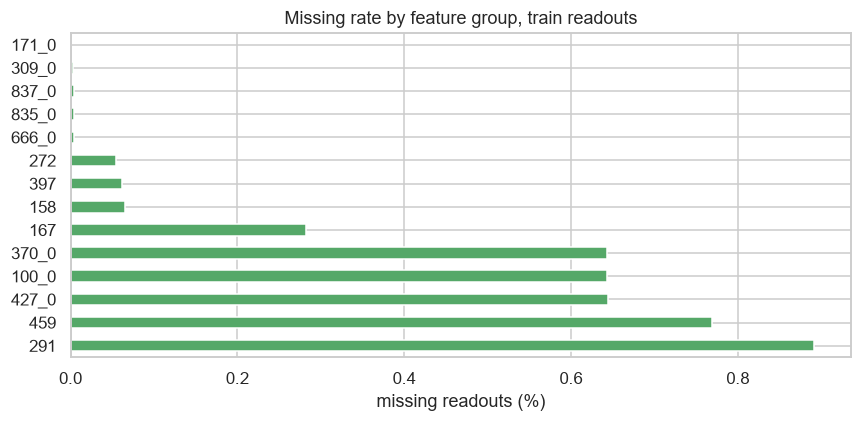

In [10]:
null_rate = readouts.isna().mean()
null_by_family = pd.Series(
    {f: null_rate[histogram_columns(f)].mean() for f in HISTOGRAM_BINS}
    | {c: null_rate[c] for c in COUNTERS}
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
null_by_family.mul(100).plot.barh(ax=ax, color="#55A868")
ax.set_xlabel("missing readouts (%)")
ax.set_title("Missing rate by feature group, train readouts")
plt.tight_layout()

In [11]:
family_291 = histogram_columns("291")
co_missing = readouts[family_291].isna().sum(axis=1).value_counts().sort_index()
co_missing.rename("rows").to_frame().T

,0,11
rows,926600,8336


Family 291 is either fully present or fully absent in a row - never partially. So impute (or
mask) at family level, not column level, and add an explicit `291_reported` indicator: a
component that stopped reporting is itself a signal.

## 4. The time axis

`time_step` is a float per-vehicle operating clock, not a wall-clock timestamp. For a
real-time system the question is: how often does a truck report, and how regular is it?

In [12]:
per_vehicle = readouts.groupby(VEHICLE_ID)[TIME_STEP].agg(
    readouts="size", first="min", last="max"
)
per_vehicle["span"] = per_vehicle["last"] - per_vehicle["first"]
per_vehicle.describe().round(2)

,readouts,first,last,span
count,18639.00,18639.00,18639.00,18639.00
mean,50.16,7.66,249.15,241.49
std,28.33,9.85,88.99,89.48
min,5.00,0.00,37.00,29.40
25%,29.00,2.60,172.20,165.00
50%,47.00,5.20,243.80,235.80
75%,68.00,9.60,319.40,311.60
max,303.00,316.40,507.40,504.20


In [13]:
gaps = readouts.groupby(VEHICLE_ID)[TIME_STEP].diff().dropna()
gap_summary = gaps.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2)
gap_summary

count    916297.00
mean          4.91
std           5.23
min           0.20
5%            0.20
25%           1.60
50%           4.60
75%           6.20
95%          12.40
99%          26.80
max         387.80
Name: time_step, dtype: float64

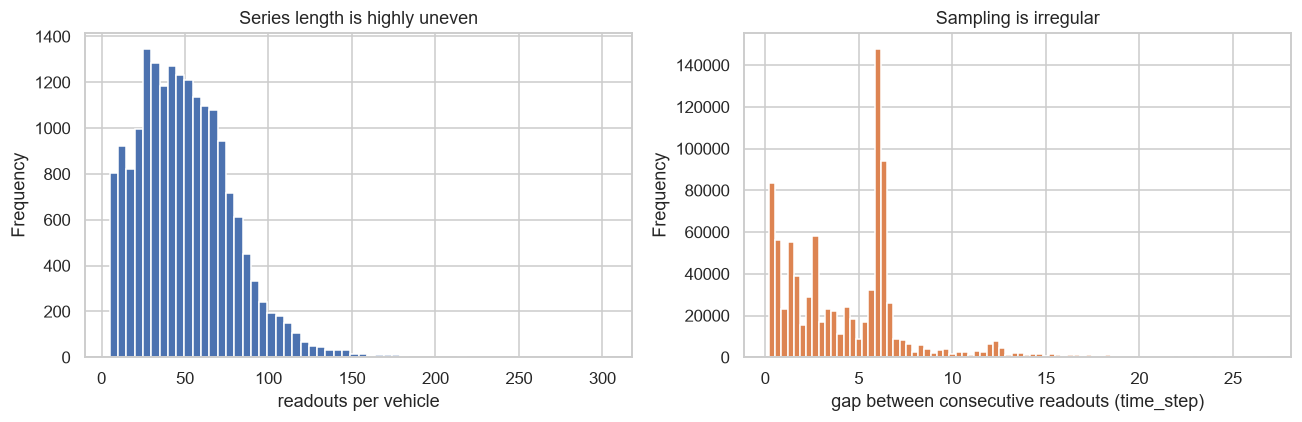

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
per_vehicle["readouts"].plot.hist(bins=60, ax=axes[0], color="#4C72B0")
axes[0].set(xlabel="readouts per vehicle", title="Series length is highly uneven")
gaps[gaps < gaps.quantile(0.99)].plot.hist(bins=80, ax=axes[1], color="#DD8452")
axes[1].set(xlabel="gap between consecutive readouts (time_step)", title="Sampling is irregular")
plt.tight_layout()

**Finding 2 - this is an irregularly sampled series, not a fixed-rate one.**
Gaps range from 0.2 to hundreds of time steps and series length varies from 5 to 300+
readouts. Any model that assumes a fixed stride (plain CNN/RNN over raw rows, fixed-length
sliding windows) is implicitly modelling "number of readouts ago" rather than elapsed
operating time. Either resample onto a regular grid or feed the gap as a feature.

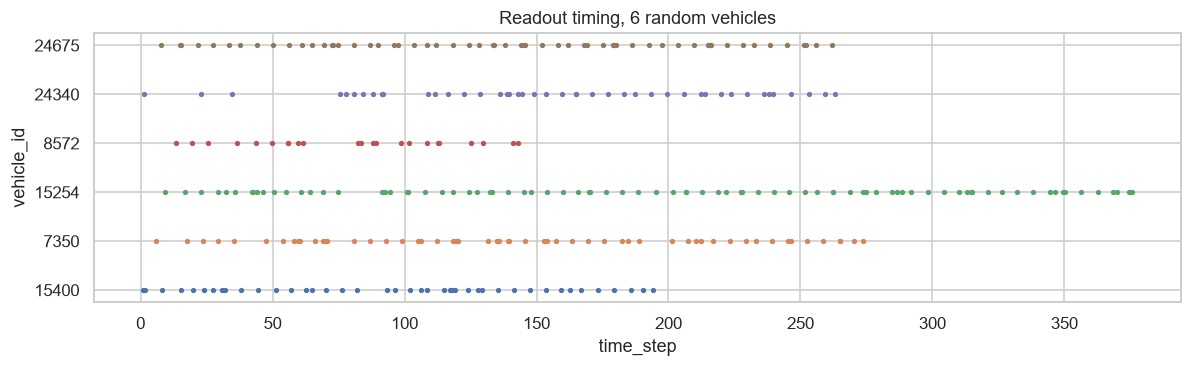

In [15]:
sample_ids = readouts[VEHICLE_ID].drop_duplicates().sample(6, random_state=0)
fig, ax = plt.subplots(figsize=(11, 3.5))
for offset, vid in enumerate(sample_ids):
    t = readouts.loc[readouts[VEHICLE_ID] == vid, TIME_STEP]
    ax.scatter(t, np.full(len(t), offset), s=6)
ax.set(yticks=range(len(sample_ids)), yticklabels=sample_ids.astype(str),
       xlabel="time_step", ylabel="vehicle_id", title="Readout timing, 6 random vehicles")
plt.tight_layout()

## 5. Survival view: study length and censoring

`train_tte.csv` is a survival table: `length_of_study_time_step` is the follow-up time and
`in_study_repair` is the event indicator. Most vehicles are censored - they left the study
without a repair.

In [16]:
event_rate = tte["in_study_repair"].value_counts().rename({0: "censored", 1: "repaired"})
event_rate.to_frame("vehicles").assign(share=lambda d: (d.vehicles / d.vehicles.sum()).round(4))

,vehicles,share
in_study_repair,,
censored,16635,0.8925
repaired,2004,0.1075


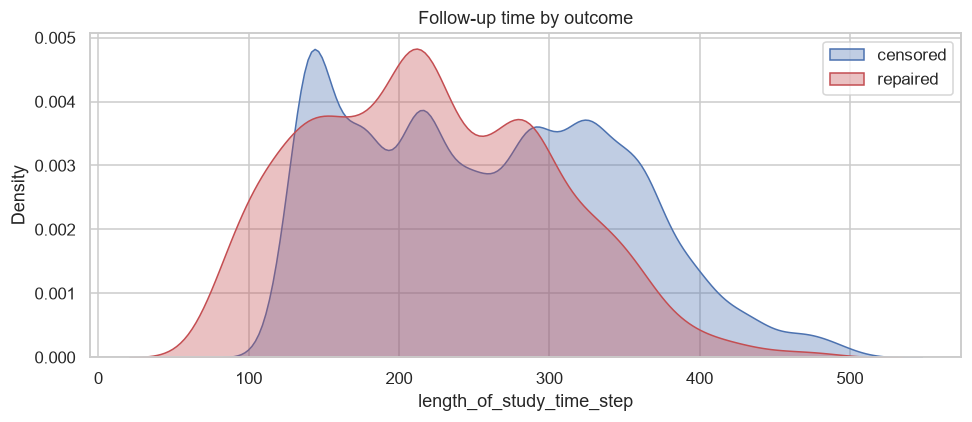

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
for flag, label in [(0, "censored"), (1, "repaired")]:
    sns.kdeplot(
        tte.loc[tte.in_study_repair == flag, "length_of_study_time_step"],
        ax=ax, fill=True, alpha=0.35, label=label, color=PALETTE[label],
    )
ax.set(xlabel="length_of_study_time_step", title="Follow-up time by outcome")
ax.legend()
plt.tight_layout()

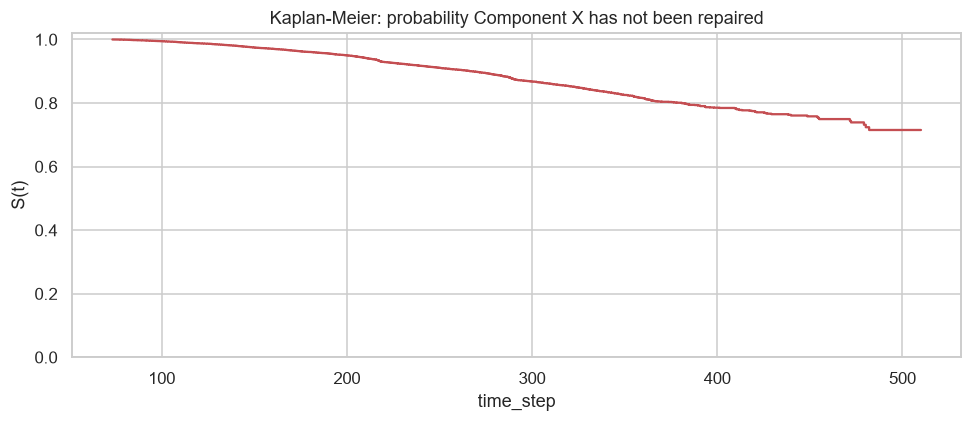

In [18]:
def kaplan_meier(durations: pd.Series, events: pd.Series) -> pd.DataFrame:
    table = (
        pd.DataFrame({"t": durations.to_numpy(), "e": events.to_numpy()})
        .groupby("t")
        .agg(events=("e", "sum"), exits=("e", "size"))
        .sort_index()
    )
    at_risk = len(durations) - table["exits"].cumsum().shift(fill_value=0)
    table["survival"] = (1 - table["events"] / at_risk).cumprod()
    table["at_risk"] = at_risk
    return table


km = kaplan_meier(tte["length_of_study_time_step"], tte["in_study_repair"])

fig, ax = plt.subplots(figsize=(9, 4))
ax.step(km.index, km["survival"], where="post", color=PALETTE["repaired"])
ax.set(xlabel="time_step", ylabel="S(t)", ylim=(0, 1.02),
       title="Kaplan-Meier: probability Component X has not been repaired")
plt.tight_layout()

**Finding 3 - censoring is the defining property of this dataset.**
~89% of vehicles never experience the event inside the study. A plain binary classifier on
"was repaired" throws away the fact that a censored truck at t=100 is *not* a confirmed
healthy truck at t=500. This is why the dataset supports survival analysis, and why survival
models (Cox, RSF, discrete-time hazard) are usually the right first reach here rather than
RUL regression.

### Readouts stop before the study ends

Aligning the last readout against the end of follow-up shows a systematic trailing gap.

In [19]:
tail_gap = (
    tte.set_index(VEHICLE_ID)["length_of_study_time_step"]
    - per_vehicle["last"]
).dropna()
tail_gap.describe(percentiles=[0.5, 0.9, 0.99]).round(2)

count    18639.00
mean         5.89
std         12.35
min          0.20
50%          2.20
90%         14.00
99%         54.80
max        324.60
dtype: float64

Median ~2 time steps, but the tail runs to hundreds. For a repaired truck the last readout
is therefore *not* the moment of failure - it is some unknown distance before it. Any
"time until event" target computed from the last readout inherits that noise, and vehicles
with a huge trailing gap should be excluded from close-to-failure training windows.

## 6. Counters: are they cumulative?

If the eight scalar features are lifetime counters, their raw level mostly encodes vehicle
age and the informative quantity is the *rate*. Check monotonicity per vehicle, ignoring
NaNs (a NaN anywhere makes a naive `is_monotonic_increasing` return False and will fool you
into thinking the counters reset).

In [20]:
ordered = readouts.sort_values([VEHICLE_ID, TIME_STEP])
monotonicity = pd.DataFrame(
    [
        {
            "counter": c,
            "observed_diffs": int(d.notna().sum()),
            "negative_diffs": int((d < 0).sum()),
            "min_diff": float(d.min()),
        }
        for c, d in ((c, ordered.groupby(VEHICLE_ID)[c].diff()) for c in COUNTERS)
    ]
)
monotonicity

,counter,observed_diffs,negative_diffs,min_diff
0,171_0,916297,7,-15.0
1,666_0,916222,0,0.0
2,427_0,908126,0,0.0
3,837_0,916224,0,0.0
4,309_0,916233,0,0.0
5,835_0,916225,0,0.0
6,370_0,908136,0,0.0
7,100_0,908131,0,0.0


**Finding 4 - the counters are cumulative and essentially never reset.**
Out of ~900k consecutive pairs per counter, negative steps are at most a handful. So the raw
level is a proxy for accumulated usage; the modelling signal is in the derivative.

In [21]:
rates = ordered.groupby(VEHICLE_ID)[list(COUNTERS)].diff()
rates["dt"] = ordered.groupby(VEHICLE_ID)[TIME_STEP].diff()
rates = rates[rates["dt"] > 0]
per_step = rates[list(COUNTERS)].div(rates["dt"], axis=0)
per_step.describe(percentiles=[0.5, 0.95]).round(2).T

,count,mean,std,min,50%,95%,max
171_0,916297.0,23910.66,13845.35,-75.01,24064.28,47546.68,2.276241e+05
666_0,916222.0,852.10,943.52,0.00,598.50,2598.51,9.451070e+04
427_0,908126.0,908734.94,482661.94,0.00,913558.12,1720581.75,2.367000e+07
837_0,916224.0,325.26,893.32,0.00,111.11,1360.49,6.599248e+05
309_0,916233.0,96.58,540.04,0.00,0.17,478.50,3.162588e+05
835_0,916225.0,1028637.44,547999.94,0.00,1010685.50,1889870.50,1.076040e+08
370_0,908136.0,47974.05,125012.42,0.00,0.00,303572.00,2.573950e+06
100_0,908131.0,102753.34,80385.23,0.00,85584.43,235917.00,6.603886e+06


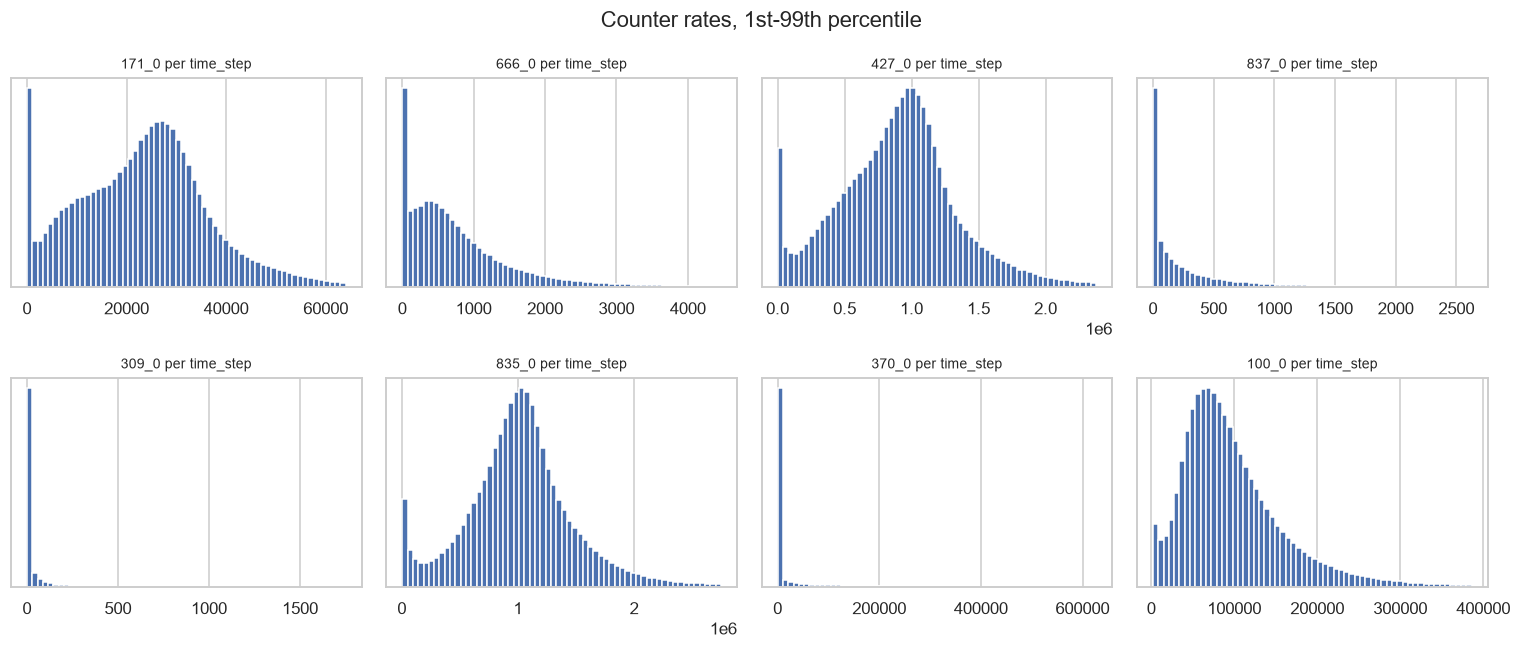

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, c in zip(axes.ravel(), COUNTERS):
    values = per_step[c].replace([np.inf, -np.inf], np.nan).dropna()
    clipped = values[values.between(values.quantile(0.01), values.quantile(0.99))]
    ax.hist(clipped, bins=60, color="#4C72B0")
    ax.set_title(f"{c} per time_step", fontsize=9)
    ax.set_yticks([])
fig.suptitle("Counter rates, 1st-99th percentile")
plt.tight_layout()

## 7. Histograms as distributions

Row-normalise each family so the bins become a shape rather than a volume. That separates
"how much the truck was used" (already captured by the counters) from "how it was used".

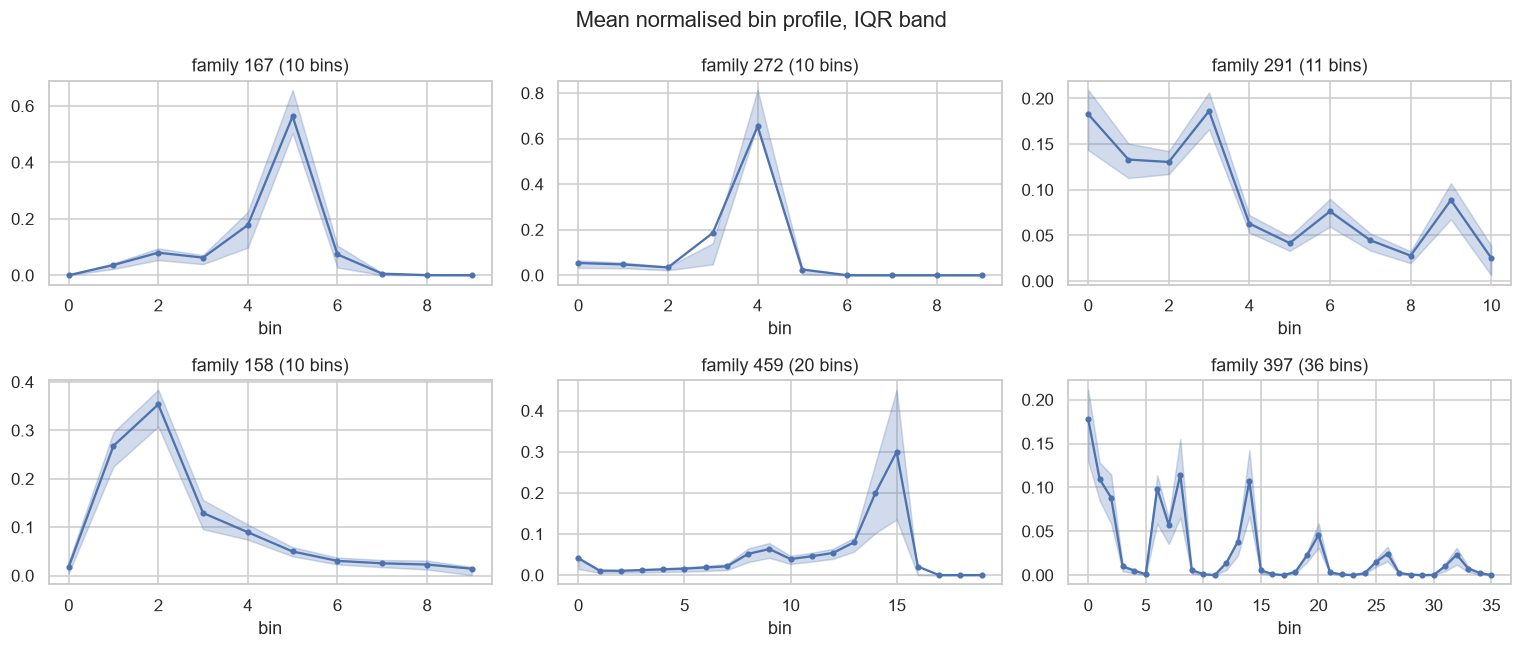

In [23]:
normalised = {}
for family in HISTOGRAM_BINS:
    cols = histogram_columns(family)
    block = readouts[cols]
    normalised[family] = block.div(block.sum(axis=1).replace(0, np.nan), axis=0)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, (family, block) in zip(axes.ravel(), normalised.items()):
    ax.plot(range(block.shape[1]), block.mean(), marker="o", ms=3, color="#4C72B0")
    ax.fill_between(
        range(block.shape[1]),
        block.quantile(0.25),
        block.quantile(0.75),
        alpha=0.25,
        color="#4C72B0",
    )
    ax.set(title=f"family {family} ({HISTOGRAM_BINS[family]} bins)", xlabel="bin")
fig.suptitle("Mean normalised bin profile, IQR band")
plt.tight_layout()

Families 167, 272, 158 and 397 are strongly mass-concentrated in a few bins - most trucks
operate in a narrow band and the tail bins are the rare, interesting regime. Families 291
and 459 are broader.

### Does the profile shift as a vehicle ages?

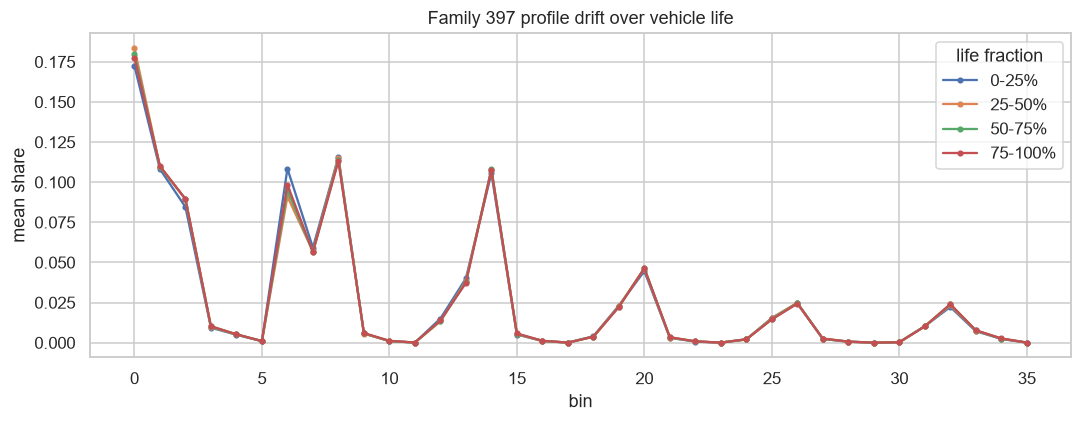

In [24]:
family = "397"
block = normalised[family].copy()
block[VEHICLE_ID] = readouts[VEHICLE_ID].to_numpy()
block["life_fraction"] = (
    readouts[TIME_STEP].to_numpy()
    / readouts[VEHICLE_ID].map(per_vehicle["last"]).replace(0, np.nan).to_numpy()
)
block["life_bucket"] = pd.cut(block["life_fraction"], [0, 0.25, 0.5, 0.75, 1.0], labels=["0-25%", "25-50%", "50-75%", "75-100%"])

drift = block.groupby("life_bucket", observed=True)[histogram_columns(family)].mean()

fig, ax = plt.subplots(figsize=(10, 4))
for bucket, row in drift.iterrows():
    ax.plot(range(len(row)), row.to_numpy(), marker="o", ms=3, label=bucket)
ax.set(xlabel="bin", ylabel="mean share", title=f"Family {family} profile drift over vehicle life")
ax.legend(title="life fraction")
plt.tight_layout()

## 8. Where is the failure signal?

Compare the last observed readout of repaired vehicles against the last readout of censored
vehicles. Standardised mean difference (Cohen's d) ranks the features by separation.

In [25]:
last_readout = ordered.groupby(VEHICLE_ID).tail(1).set_index(VEHICLE_ID)
last_readout = last_readout.join(tte.set_index(VEHICLE_ID)["in_study_repair"], how="inner")

feature_cols = list(COUNTERS) + all_histogram_columns()
repaired = last_readout[last_readout.in_study_repair == 1][feature_cols]
censored = last_readout[last_readout.in_study_repair == 0][feature_cols]

pooled_sd = np.sqrt((repaired.var() + censored.var()) / 2)
cohens_d = ((repaired.mean() - censored.mean()) / pooled_sd).replace([np.inf, -np.inf], np.nan).dropna()
effect = cohens_d.reindex(cohens_d.abs().sort_values(ascending=False).index)
effect.head(15).to_frame("cohens_d").round(3)

,cohens_d
167_2,-0.248
272_1,-0.238
167_1,-0.231
167_3,-0.220
272_0,-0.212
291_3,-0.196
837_0,0.187
397_33,0.186
459_15,0.185
158_8,0.178


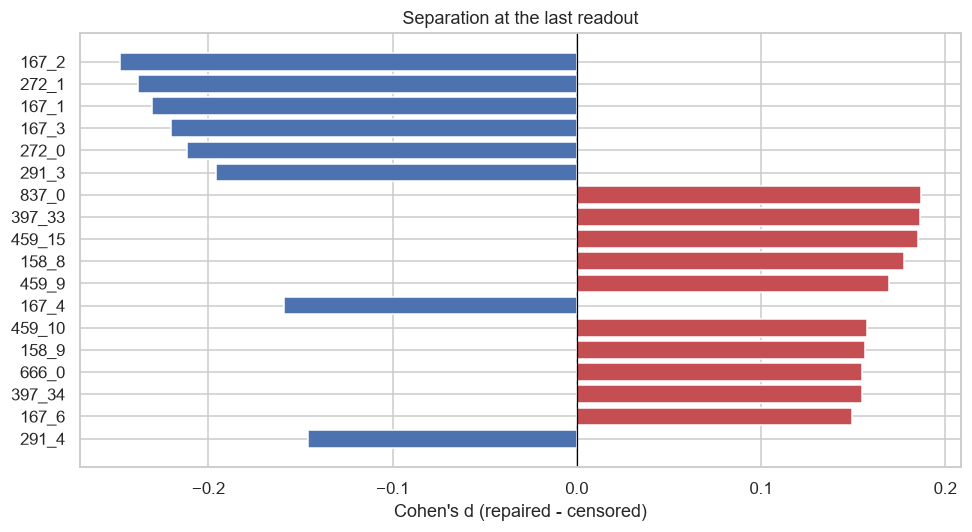

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
top = effect.head(18)[::-1]
ax.barh(top.index, top.to_numpy(), color=np.where(top.to_numpy() > 0, PALETTE["repaired"], PALETTE["censored"]))
ax.axvline(0, color="black", lw=0.8)
ax.set(xlabel="Cohen's d (repaired - censored)", title="Separation at the last readout")
plt.tight_layout()

**Finding 5 - the separation is modest, and operating time cuts against the obvious story.**
The largest effects (|d| about 0.25) sit in histogram families 167 and 272, not in the
counters. And repaired vehicles are *younger* at their last readout (median 212 vs 249 time
steps), because the repair ends their series early. Raw counter levels are therefore
confounded downward by age, not upward. Condition on operating time before trusting any
single feature.

In [27]:
last_readout["time_step"] = ordered.groupby(VEHICLE_ID)[TIME_STEP].max()
age_effect = (
    last_readout.groupby("in_study_repair")["time_step"].agg(["mean", "median", "count"]).round(1)
)
age_effect

,mean,median,count
in_study_repair,,,
0,253.000000,249.199997,16635
1,217.399994,212.000000,2004


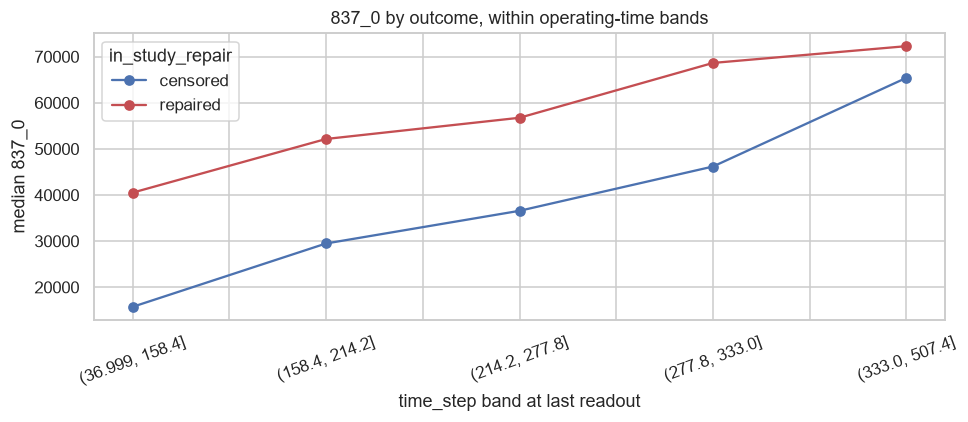

In [28]:
top_counter = effect.reindex(list(COUNTERS)).abs().idxmax()
bands = pd.qcut(last_readout["time_step"], 5, duplicates="drop")
conditioned = (
    last_readout.groupby([bands, "in_study_repair"], observed=True)[top_counter]
    .median()
    .unstack()
    .rename(columns={0: "censored", 1: "repaired"})
)

fig, ax = plt.subplots(figsize=(9, 4))
conditioned.plot(marker="o", ax=ax, color=[PALETTE["censored"], PALETTE["repaired"]])
ax.set(xlabel="time_step band at last readout", ylabel=f"median {top_counter}",
       title=f"{top_counter} by outcome, within operating-time bands")
plt.xticks(rotation=20)
plt.tight_layout()

If the two lines stay apart inside every band, the counter carries information beyond age.
If they converge, the apparent effect was age all along - and the model needs
usage-normalised features (counter per time_step) rather than raw levels.

## 9. Specifications

Eight anonymised categorical attributes per vehicle - the static context (model variant,
market, drivetrain, etc.). Cramer's V against the repair flag measures association.

In [29]:
specs = train.specifications.merge(tte[[VEHICLE_ID, "in_study_repair"]], on=VEHICLE_ID)
specs[list(SPEC_COLUMNS)].nunique().to_frame("distinct_values").T

,Spec_0,Spec_1,Spec_2,Spec_3,Spec_4,Spec_5,Spec_6,Spec_7
distinct_values,3,28,21,4,2,5,16,9


In [30]:
def cramers_v(a: pd.Series, b: pd.Series) -> float:
    table = pd.crosstab(a, b).to_numpy()
    n = table.sum()
    expected = np.outer(table.sum(1), table.sum(0)) / n
    chi2 = ((table - expected) ** 2 / expected).sum()
    return float(np.sqrt((chi2 / n) / (min(table.shape) - 1)))


association = (
    pd.Series({c: cramers_v(specs[c], specs["in_study_repair"]) for c in SPEC_COLUMNS})
    .sort_values(ascending=False)
)
association.to_frame("cramers_v").round(4)

,cramers_v
Spec_2,0.1077
Spec_1,0.0942
Spec_7,0.0939
Spec_3,0.0814
Spec_6,0.0755
Spec_0,0.0555
Spec_4,0.0413
Spec_5,0.0262


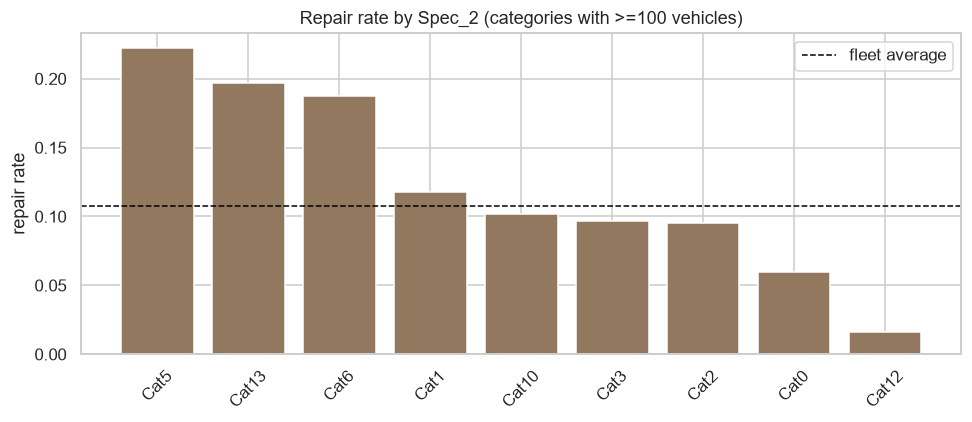

In [31]:
strongest = association.index[0]
by_spec = (
    specs.groupby(strongest)["in_study_repair"]
    .agg(vehicles="size", repair_rate="mean")
    .sort_values("repair_rate", ascending=False)
)
by_spec = by_spec[by_spec.vehicles >= 100]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(by_spec.index.astype(str), by_spec["repair_rate"], color="#937860")
ax.axhline(specs["in_study_repair"].mean(), color="black", ls="--", lw=1, label="fleet average")
ax.set(ylabel="repair rate", title=f"Repair rate by {strongest} (categories with >=100 vehicles)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()

Specs are cheap, always present, and never missing - a good backstop for the vehicles that
have no telemetry at all (section 1). But note the class-imbalance trap: a category with 30
vehicles and 2 repairs looks alarming and means nothing.

## 10. Validation and test: a different labelling scheme

Train gives you time-to-event. Validation and test give a 5-class label describing how far
the (truncated) series ends from the repair. Each vehicle's series is cut at a randomly
chosen readout, so the truncation point itself is a nuisance variable.

In [32]:
pd.Series(CLASS_WINDOWS).to_frame("meaning")

,meaning
0,> 48 steps to failure (or healthy)
1,48-24 steps to failure
2,24-12 steps to failure
3,12-6 steps to failure
4,6-0 steps to failure


In [33]:
label_dist = pd.concat(
    {
        "validation": validation.labels["class_label"].value_counts().sort_index(),
        "test": test.labels["class_label"].value_counts().sort_index(),
    },
    axis=1,
).fillna(0).astype(int)
label_dist.assign(
    validation_share=lambda d: (d.validation / d.validation.sum()).round(4),
    test_share=lambda d: (d.test / d.test.sum()).round(4),
)

,validation,test,validation_share,test_share
class_label,,,,
0,4910,4903,0.9730,0.9719
1,16,26,0.0032,0.0052
2,14,15,0.0028,0.0030
3,30,41,0.0059,0.0081
4,76,60,0.0151,0.0119


**Finding 6 - the positive classes are ~1-2% of vehicles combined.**
Classes 1-4 together are around 130 of 5,046 vehicles. Accuracy is meaningless here; the
challenge defines a cost matrix instead.

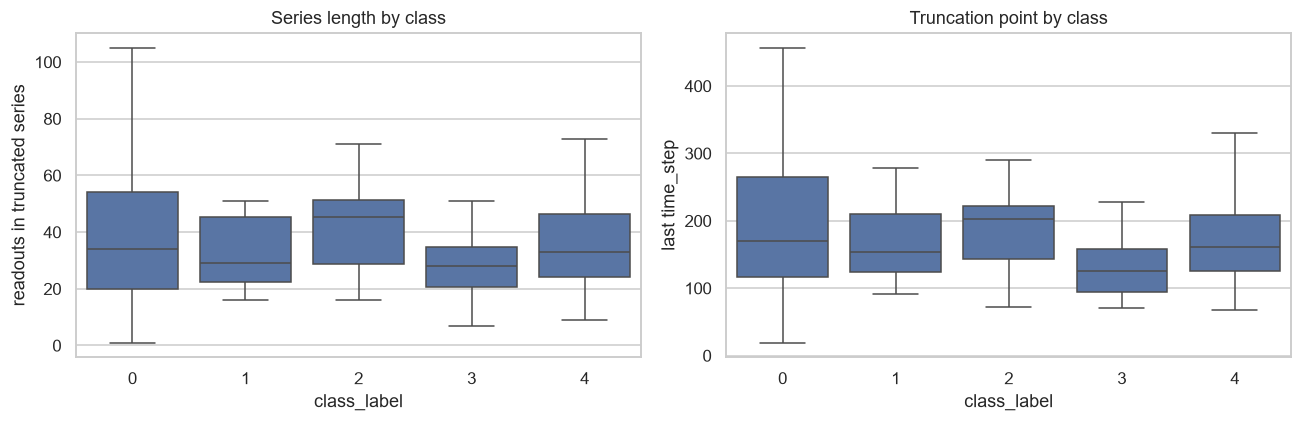

In [34]:
val_lengths = validation.readouts.groupby(VEHICLE_ID)[TIME_STEP].agg(["size", "max"])
val_lengths = val_lengths.join(validation.labels.set_index(VEHICLE_ID)["class_label"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=val_lengths, x="class_label", y="size", ax=axes[0], showfliers=False)
axes[0].set(ylabel="readouts in truncated series", title="Series length by class")
sns.boxplot(data=val_lengths, x="class_label", y="max", ax=axes[1], showfliers=False)
axes[1].set(ylabel="last time_step", title="Truncation point by class")
plt.tight_layout()

If series length or last `time_step` differs systematically by class, a model can score well
by reading the truncation rather than the degradation. Check this before celebrating any
metric: it is the single most likely source of a leak in this dataset.

## 11. The cost matrix, and what a trivial model costs

Rows are the true class, columns the prediction. Missing a failing truck costs 200-500;
an unnecessary workshop check costs 7-10. The asymmetry is roughly 20-70x.

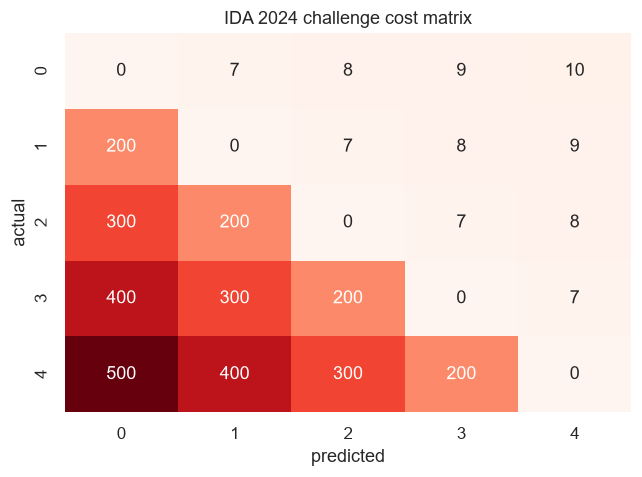

In [35]:
cost_frame = pd.DataFrame(
    COST_MATRIX,
    index=pd.Index(range(5), name="actual"),
    columns=pd.Index(range(5), name="predicted"),
)
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(cost_frame, annot=True, fmt="d", cmap="Reds", cbar=False, ax=ax)
ax.set_title("IDA 2024 challenge cost matrix")
plt.tight_layout()

In [36]:
y_val = validation.labels["class_label"].to_numpy()
baselines = pd.Series(constant_prediction_costs(y_val)).to_frame("total_cost")
baselines["cost_per_vehicle"] = (baselines.total_cost / len(y_val)).round(2)
baselines.index.name = "constant prediction"
baselines

,total_cost,cost_per_vehicle
constant prediction,,
0,57400,11.38
1,76570,15.17
2,68192,13.51
3,59616,11.81
4,49566,9.82


**Finding 7 - "predict the majority class" is not the cheapest trivial model.**
Sending *every* truck to the workshop as class 4 costs 49,566 against 57,400 for predicting
class 0 everywhere, even though class 0 is 97% of the fleet. That is the cost asymmetry
talking: a missed class-4 truck costs 500 and a false alarm costs 10, so flagging 50 extra
trucks to catch one real failure is still profitable. Always-4 is the baseline to beat, and
any decision threshold tuned on F1 or accuracy will be far too conservative.

In [37]:
rng = np.random.default_rng(0)
prevalence = np.bincount(y_val, minlength=5) / len(y_val)
stochastic = rng.choice(5, size=len(y_val), p=prevalence)
pd.Series(
    {
        "always 0": total_cost(y_val, np.zeros_like(y_val)),
        "sample from prevalence": total_cost(y_val, stochastic),
        "perfect": total_cost(y_val, y_val),
    }
).to_frame("total_cost")

,total_cost
always 0,57400
sample from prevalence,55875
perfect,0


## 12. Takeaways for modelling

| # | Observation | Consequence |
|---|---|---|
| 1 | ~21% of labelled train vehicles have no readouts, with half the repair rate | Model them as a separate spec-only cohort; do not drop silently |
| 2 | Sampling is irregular (gaps 0.2 to 100s of steps, 5-300 readouts per vehicle) | Resample to a grid or feed `dt` explicitly; no fixed-stride windows |
| 3 | ~89% of outcomes are censored | Survival models over plain binary classification |
| 4 | Counters are cumulative and never reset | Use per-time_step rates, not raw levels |
| 5 | Histogram families are mass-concentrated and vary in scale | Row-normalise per family; keep volume in the counters |
| 6 | Missingness arrives per family, not per column | Impute at family level, add a `reported` indicator |
| 7 | Last readout sits a variable distance before the event | Noisy TTE target; exclude large trailing gaps from tight windows |
| 8 | Val/test series are randomly truncated | Audit for truncation leakage before trusting any score |
| 9 | Cost asymmetry is 20-70x, so always-4 (49,566) beats always-0 (57,400) | Optimise expected cost directly; never threshold on F1 |

Suggested next notebook: build a vehicle-level feature table (last-window counter rates,
normalised histogram shapes, spec one-hots, `dt` statistics), fit a discrete-time hazard
model, and tune the decision rule against the cost matrix rather than a classification metric.